<a href="https://colab.research.google.com/github/NehaBongarde2004/Deep-Learning/blob/main/DL_Exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1, 28*28) / 255.0
x_test = x_test.reshape(-1, 28*28) / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def create_model(lr):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(784,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
model_fixed = create_model(lr=0.001)

history_fixed = model_fixed.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8588 - loss: 0.4768 - val_accuracy: 0.9603 - val_loss: 0.1373
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9653 - loss: 0.1146 - val_accuracy: 0.9598 - val_loss: 0.1313
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9774 - loss: 0.0764 - val_accuracy: 0.9708 - val_loss: 0.0963
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9848 - loss: 0.0523 - val_accuracy: 0.9710 - val_loss: 0.1030
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9874 - loss: 0.0400 - val_accuracy: 0.9696 - val_loss: 0.1060
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9880 - loss: 0.0359 - val_accuracy: 0.9715 - val_loss: 0.1039
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9921 - loss: 0.0248 - val_accuracy: 0.9711 - val_loss: 0.1033
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9937 - loss: 0.0192 - 

In [ ]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

model_lr = create_model(lr=0.001)

history_lr = model_lr.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32,
    callbacks=[lr_scheduler],
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8674 - loss: 0.4550 - val_accuracy: 0.9574 - val_loss: 0.1432 - learning_rate: 0.0010
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9627 - loss: 0.1208 - val_accuracy: 0.9643 - val_loss: 0.1141 - learning_rate: 0.0010
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9767 - loss: 0.0750 - val_accuracy: 0.9693 - val_loss: 0.1017 - learning_rate: 0.0010
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9825 - loss: 0.0563 - val_accuracy: 0.9732 - val_loss: 0.0922 - learning_rate: 0.0010
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9857 - loss: 0.0441 - val_accuracy: 0.9744 - val_loss: 0.0933 - learning_rate: 0.0010
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9890 - loss: 0.0343 - val_accuracy: 0.9742 - val_loss: 0.0985 - learning_rate: 0.0010
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9919 - l

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

model_es = create_model(lr=0.001)

history_es = model_es.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8590 - loss: 0.4767 - val_accuracy: 0.9582 - val_loss: 0.1432
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9649 - loss: 0.1121 - val_accuracy: 0.9683 - val_loss: 0.1114
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9776 - loss: 0.0708 - val_accuracy: 0.9679 - val_loss: 0.1066
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9841 - loss: 0.0540 - val_accuracy: 0.9712 - val_loss: 0.1009
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9879 - loss: 0.0393 - val_accuracy: 0.9750 - val_loss: 0.0944
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9906 - loss: 0.0303 - val_accuracy: 0.9732 - val_loss: 0.1006
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9914 - loss: 0.0276 - val_accuracy: 0.9745 - val_loss: 0.1051
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9919 - loss: 0.0223 -

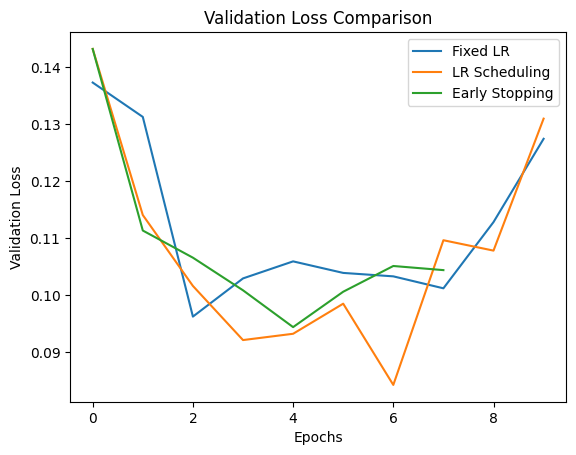

In [ ]:
plt.plot(history_fixed.history['val_loss'], label='Fixed LR')
plt.plot(history_lr.history['val_loss'], label='LR Scheduling')
plt.plot(history_es.history['val_loss'], label='Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.title('Validation Loss Comparison')
plt.show()